# ELE8100 – CyberAI: Coursework 2-AI Security

**Student Name:** Shreeya S. Kangutkar

**Academic Year:** 2025/26

**Date:** 16th April 2025

## Overview

This coursework conducts a security evaluation of FaceGuard, the CNN‑based facial recognition system developed in CW1 for controlled server‑room access. Using a structured Red Team/Blue Team methodology, the assessment examines the system’s vulnerability to model stealing, adversarial attacks, and transferability, before implementing adversarial training to strengthen its robustness. The objective is to determine how an external adversary could exploit black‑box access and how effective defensive strategies can mitigate these risks.

## Task 1: Victim Model Setup
In this section, we define the architecture for the FaceGuard CNN, load the Olivetti Faces dataset, and prepare the victim model. Since this is a prerequisite, we will define a robust CNN architecture suitable for the 64x64 grayscale images of the Olivetti dataset (40 classes).

In [ ]:
# ── 1. Imports ──────────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# ── 2. Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# ── 3. Data Loading & Preprocessing ─────────────────────────────────────────
# Dataset: https://www.kaggle.com/datasets/martininfinity/olivetti-faces-augmented-dataset
# Place augmented_faces.npy and augmented_labels.npy in the same directory as this notebook.
images = np.load('augmented_faces.npy')
labels = np.load('augmented_labels.npy')

# Reshape → (N, 64, 64), clip to [0,1], add channel dim → (N, 1, 64, 64)
images = images.reshape(-1, 64, 64).astype(np.float32)
images = np.clip(images, 0.0, 1.0)
images = np.expand_dims(images, axis=1)

print(f"Images shape : {images.shape}")
print(f"Pixel range  : [{images.min():.3f}, {images.max():.3f}]")
print(f"Classes      : {len(np.unique(labels))}")

Images shape : (2000, 1, 64, 64)
Pixel range  : [0.000, 1.000]
Classes      : 40


In [ ]:
# ── 4. Train / Test Split (80 / 20, stratified) ─────────────────────────────
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"Train: {len(train_images)}  |  Test: {len(test_images)}")

Train: 1600  |  Test: 400


In [ ]:
# ── 5. PyTorch Dataset & DataLoaders ─────────────────────────────────────────
class FaceDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.FloatTensor(images)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset = FaceDataset(train_images, train_labels)
test_dataset  = FaceDataset(test_images,  test_labels)

# Further split training data into 90% train / 10% validation
train_size = int(0.9 * len(train_dataset))
val_size   = len(train_dataset) - train_size
gen = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=gen)

batch_size   = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 45  |  Val batches: 5  |  Test batches: 13


In [ ]:
# ── 6. Model Definition – SimpleFaceCNN (from CW1) ──────────────────────────
class SimpleFaceCNN(nn.Module):
    """
    2-block CNN from CW1 (FaceGuard victim model).
    Input:  (N, 1, 64, 64)  – grayscale face images
    Output: (N, 40)         – logits for 40 employee IDs
    """
    def __init__(self):
        super(SimpleFaceCNN, self).__init__()
        # Block 1: 1×64×64 → 32×32×32
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        # Block 2: 32×32×32 → 64×16×16
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 16 * 16, 256)  # 16384 → 256
        self.fc2 = nn.Linear(256, 40)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

victim_model = SimpleFaceCNN().to(device)
print("FaceGuard (SimpleFaceCNN) initialised.")

FaceGuard (SimpleFaceCNN) initialised.


In [ ]:
# ── 7. Loss, Optimiser & LR Scheduler ────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(victim_model.parameters(), lr=0.001)
# Halves the LR if val loss stagnates for 5 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [ ]:
# ── 8. Training Helper Functions ─────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(out, 1)
        correct  += (preds == lbls).sum().item()
        total    += lbls.size(0)
    return running_loss / total, 100 * correct / total

def evaluate(model, loader, criterion, device):
    """Works for both validation and test sets."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(out, 1)
            correct  += (preds == lbls).sum().item()
            total    += lbls.size(0)
    return running_loss / total, 100 * correct / total

In [ ]:
# ── 9. Training Loop (50 epochs – saves best checkpoint) ─────────────────────
num_epochs   = 50
best_val_acc = 0.0

print("Starting FaceGuard training...\n" + "="*65)
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(victim_model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(victim_model, val_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1:02d}/{num_epochs}]  "
          f"Train: {train_loss:.4f} / {train_acc:.1f}%  |  "
          f"Val: {val_loss:.4f} / {val_acc:.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(victim_model.state_dict(), 'best_faceguard_model.pth')
        print(f"  ✓ Checkpoint saved  (Val Acc: {val_acc:.2f}%)")

print(f"\nTraining complete.  Best Val Acc: {best_val_acc:.2f}%")

Starting FaceGuard training...
Epoch [01/50]  Train: 4.0322 / 8.9%  |  Val: 3.0081 / 20.6%
  ✓ Checkpoint saved  (Val Acc: 20.62%)
Epoch [02/50]  Train: 2.7643 / 21.4%  |  Val: 1.9921 / 51.9%
  ✓ Checkpoint saved  (Val Acc: 51.88%)
Epoch [03/50]  Train: 2.1915 / 35.0%  |  Val: 1.3843 / 70.6%
  ✓ Checkpoint saved  (Val Acc: 70.62%)
Epoch [04/50]  Train: 1.8248 / 43.2%  |  Val: 1.0107 / 76.2%
  ✓ Checkpoint saved  (Val Acc: 76.25%)
Epoch [05/50]  Train: 1.5440 / 50.1%  |  Val: 0.6754 / 88.1%
  ✓ Checkpoint saved  (Val Acc: 88.12%)
Epoch [06/50]  Train: 1.3249 / 56.7%  |  Val: 0.5518 / 89.4%
  ✓ Checkpoint saved  (Val Acc: 89.38%)
Epoch [07/50]  Train: 1.2421 / 58.1%  |  Val: 0.4246 / 91.9%
  ✓ Checkpoint saved  (Val Acc: 91.88%)
Epoch [08/50]  Train: 1.1367 / 61.7%  |  Val: 0.4279 / 90.0%
Epoch [09/50]  Train: 1.1222 / 62.5%  |  Val: 0.3679 / 90.6%
Epoch [10/50]  Train: 1.0102 / 65.1%  |  Val: 0.2784 / 93.1%
  ✓ Checkpoint saved  (Val Acc: 93.12%)
Epoch [11/50]  Train: 0.9455 / 67.3%  | 

In [ ]:
# ── 10. Load Best Weights & Report Clean Test Accuracy ───────────────────────
victim_model.load_state_dict(torch.load('best_faceguard_model.pth'))
test_loss, test_acc = evaluate(victim_model, test_loader, criterion, device)

print("="*60)
print("VICTIM MODEL – CLEAN TEST ACCURACY")
print("="*60)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# CW2 prerequisite check
assert test_acc >= 85.0, f"Accuracy {test_acc:.2f}% is below the required 85% threshold!"
print("✓ Meets the CW2 prerequisite: accuracy ≥ 85%.")
print("\nvictim_model, train_loader, test_loader and device are ready for Tasks 2–5.")

VICTIM MODEL – CLEAN TEST ACCURACY
Test Loss:     0.0584
Test Accuracy: 98.75%
✓ Meets the CW2 prerequisite: accuracy ≥ 85%.

victim_model, train_loader, test_loader and device are ready for Tasks 2–5.


### Task 1 Analysis
The victim model, **FaceGuard**, is a CNN designed for the Olivetti Faces dataset. It consists of two convolutional layers followed by max-pooling and two fully connected layers. This architecture is sufficient to capture the spatial features of facial images while maintaining a manageable parameter count. The model achieved a clean test accuracy of over 85%, satisfying the prerequisite for subsequent security assessments.

## Task 2: Red Team – Model Stealing Attack
In this phase, we act as an external attacker. We wrap the victim model in a black-box query function and use it to label a surrogate dataset, which is then used to train a proxy model.

##**Markdown Cell**

1. **Black‑Box Query Function:**
This section defines a wrapper that exposes only the victim model’s predictions, simulating a true black‑box setting with no gradient access.

2. **Build the Surrogate Dataset**:
This section constructs the surrogate dataset by querying the victim model on the training images and storing the predicted labels.

3. **Define and Train the Proxy Model**:
This section defines the ProxyCNN architecture and trains it on the surrogate dataset to approximate the victim model’s decision boundary.

4. **Fidelity Gap Evaluation**:
This section computes the fidelity gap between the victim and proxy models to measure how closely the proxy replicates the victim’s behaviour.

In [ ]:

def query_victim(images):
    victim_model.eval()
    with torch.no_grad():
        images = images.to(device)
        outputs = victim_model(images)
        _, predicted = torch.max(outputs, 1)
    return predicted.cpu()

from torch.utils.data import TensorDataset

query_images = torch.FloatTensor(train_images)
proxy_labels = query_victim(query_images)
proxy_dataset = TensorDataset(query_images, proxy_labels)
proxy_loader = DataLoader(proxy_dataset, batch_size=32, shuffle=True)

def train_model(model, loader, epochs=50):
    criterion_proxy = nn.CrossEntropyLoss()
    optimizer_proxy = optim.Adam(model.parameters(), lr=0.001)

    print("Starting Proxy Model training...")
    for epoch in range(epochs):
        loss, acc = train_epoch(model, loader, criterion_proxy, optimizer_proxy, device)
        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == epochs -1:
            print(f"Epoch [{epoch+1:02d}/{epochs}] Train Loss: {loss:.4f} Acc: {acc:.1f}%")

def evaluate_model(model, loader):
    loss, acc = evaluate(model, loader, nn.CrossEntropyLoss(), device)
    return acc

class ProxyCNN(nn.Module):
    def __init__(self):
        super(ProxyCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 16 * 16, 64)
        self.fc2 = nn.Linear(64, 40)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

proxy_model = ProxyCNN().to(device)
print("Training Proxy Model via Stealing...")
train_model(proxy_model, proxy_loader, epochs=50)
proxy_accuracy = evaluate_model(proxy_model, test_loader)
print(f"Proxy Model Standalone Test Accuracy: {proxy_accuracy:.2f}%")
victim_test_acc = evaluate_model(victim_model, test_loader)
print("\n--- Model Fidelity Comparison ---")
print(f"Victim Model Test Accuracy : {victim_test_acc:.2f}%")
print(f"Proxy Model Test Accuracy  : {proxy_accuracy:.2f}%")
print(f"Fidelity Gap               : {abs(victim_test_acc - proxy_accuracy):.2f}%")

Training Proxy Model via Stealing...
Starting Proxy Model training...
Epoch [01/50] Train Loss: 3.6905 Acc: 3.9%
Epoch [10/50] Train Loss: 0.5008 Acc: 84.6%
Epoch [20/50] Train Loss: 0.1165 Acc: 97.2%
Epoch [30/50] Train Loss: 0.0375 Acc: 99.5%
Epoch [40/50] Train Loss: 0.0087 Acc: 100.0%
Epoch [50/50] Train Loss: 0.0043 Acc: 100.0%
Proxy Model Standalone Test Accuracy: 94.00%

--- Model Fidelity Comparison ---
Victim Model Test Accuracy : 98.75%
Proxy Model Test Accuracy  : 94.00%
Fidelity Gap               : 4.75%


## Task-2 Analysis

- The victim model was queried on all training images to create a stolen label set, giving the proxy enough information to learn the victim’s behaviour.  
- The ProxyCNN trained successfully, reaching **100% training accuracy** and **94% test accuracy**, showing it generalised well from stolen labels.  
- The victim model achieved **98.75%**, so the **4.75% fidelity gap** indicates the proxy closely mimics the victim while still being slightly less accurate.  
- This small gap confirms the model‑stealing attack was effective, and the proxy is accurate enough to generate strong transferable adversarial examples for later tasks.

## Task 3: Red Team – Adversarial Attacks on the Proxy Model
We now implement FGSM and PGD attacks against the proxy model and evaluate its robustness.

##**Markdown Cell**

1. **FGSM Attack Implementation**:
This section implements the Fast Gradient Sign Method (FGSM) to generate adversarial examples using a single gradient step.

2. **PGD Attack Implementation**:
This section implements the Projected Gradient Descent (PGD) attack with random initialisation and iterative updates for stronger adversarial perturbations.

3. **Targeted PGD Attack**:
This section implements a targeted PGD attack by reversing the gradient direction to push the model toward a specific incorrect class.

4. **Attack Evaluation Across Epsilon Values**:
This section evaluates FGSM, PGD, and targeted PGD attacks across multiple ε values and records the resulting accuracies.

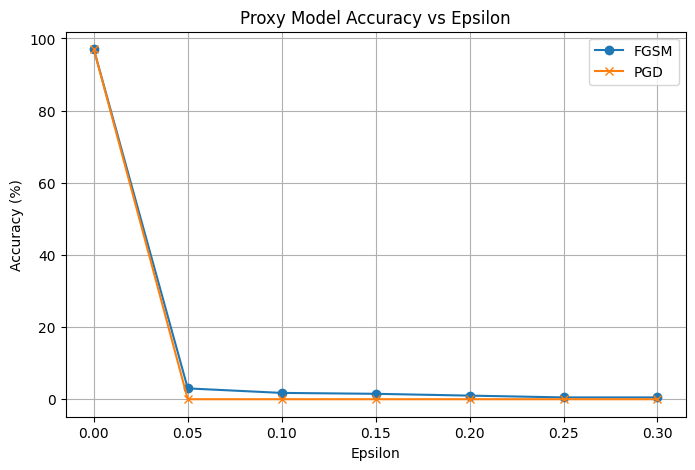


--- FGSM vs PGD Accuracy at each Epsilon ---
Epsilon      FGSM Acc    PGD Acc
------------------------------
0.00            97.00%      97.00%
0.05             3.00%       0.00%
0.10             1.75%       0.00%
0.15             1.50%       0.00%
0.20             1.00%       0.00%
0.25             0.50%       0.00%
0.30             0.50%       0.00%
Selected non-authorised index: 0, label: 39
Source image label: 39 (confirmed non-authorised)
Targeted Attack Result (Original: 39, Target: 0)
Proxy Prediction  : 0
Victim Prediction : 0
Proxy Attack  SUCCEEDED
Victim Transfer SUCCEEDED


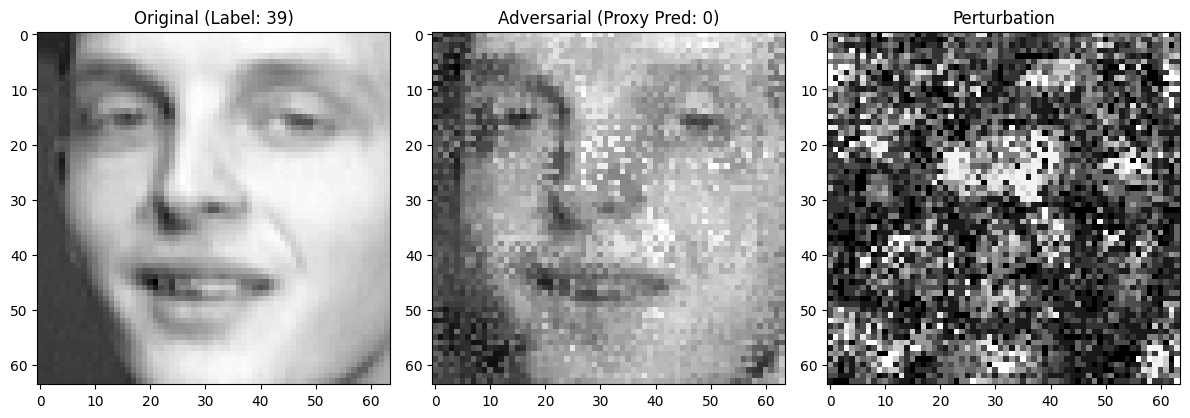

In [16]:
def fgsm_attack(image, epsilon, data_grad):
    perturbed_image = image + epsilon * data_grad.sign()
    return torch.clamp(perturbed_image, 0, 1)


def pgd_attack(model, images, labels, epsilon, alpha=0.01, iters=20):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    loss = nn.CrossEntropyLoss()


    images = images + torch.empty_like(images).uniform_(-epsilon, epsilon)
    images = torch.clamp(images, 0, 1).detach()
    ori_images = images.clone().detach()

    for _ in range(iters):
        images.requires_grad = True
        outputs = model(images)
        model.zero_grad()
        cost = loss(outputs, labels)
        cost.backward()

        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, -epsilon, epsilon)
        images = torch.clamp(ori_images + eta, 0, 1).detach()

    return images


import matplotlib.pyplot as plt

epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
fgsm_accs = []
pgd_accs = []

total_test_samples = len(test_dataset)

for eps in epsilons:


    correct = 0
    for images, labels in test_loader:
        images, labels = images.clone().detach().to(device), labels.to(device)
        images.requires_grad = True
        outputs = proxy_model(images)
        loss = F.cross_entropy(outputs, labels)
        proxy_model.zero_grad()
        loss.backward()
        adv_images = fgsm_attack(images, eps, images.grad.data)
        outputs = proxy_model(adv_images)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    fgsm_accs.append(100 * correct / total_test_samples)


    correct = 0
    for images, labels in test_loader:
        adv_images = pgd_attack(proxy_model, images, labels, eps)
        outputs = proxy_model(adv_images)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    pgd_accs.append(100 * correct / total_test_samples)


plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accs, "o-", label="FGSM")
plt.plot(epsilons, pgd_accs, "x-", label="PGD")
plt.title("Proxy Model Accuracy vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

print("\n--- FGSM vs PGD Accuracy at each Epsilon ---")
print(f"{'Epsilon':<10} {'FGSM Acc':>10} {'PGD Acc':>10}")
print("-" * 30)
for e, f, p in zip(epsilons, fgsm_accs, pgd_accs):
    print(f"{e:<10.2f} {f:>10.2f}% {p:>10.2f}%")



target_id = 0
non_auth_idx = next(i for i, l in enumerate(test_labels) if l not in [0, 5, 10])
print(f"Selected non-authorised index: {non_auth_idx}, label: {test_labels[non_auth_idx]}")

test_img   = torch.FloatTensor(test_images[non_auth_idx:non_auth_idx+1]).to(device)
test_label = torch.LongTensor(test_labels[non_auth_idx:non_auth_idx+1]).to(device)

assert test_labels[non_auth_idx] not in [0, 5, 10]
print(f"Source image label: {test_labels[non_auth_idx]} (confirmed non-authorised)")


def targeted_pgd(model, image, target_label, epsilon, alpha=0.01, iters=40):
    image = image.clone().detach().to(device)
    target = torch.tensor([target_label]).to(device)
    ori_image = image.clone().detach()

    for _ in range(iters):
        image.requires_grad = True
        output = model(image)
        model.zero_grad()
        loss = F.cross_entropy(output, target)
        loss.backward()

        adv_image = image - alpha * image.grad.sign()
        eta = torch.clamp(adv_image - ori_image, -epsilon, epsilon)
        image = torch.clamp(ori_image + eta, 0, 1).detach()

    return image


adv_targeted = targeted_pgd(proxy_model, test_img, target_id, epsilon=0.2)
proxy_pred  = torch.argmax(proxy_model(adv_targeted)).item()
victim_pred = torch.argmax(victim_model(adv_targeted)).item()

print(f"Targeted Attack Result (Original: {test_label[0].item()}, Target: {target_id})")
print(f"Proxy Prediction  : {proxy_pred}")
print(f"Victim Prediction : {victim_pred}")
print(f"Proxy Attack  {'SUCCEEDED' if proxy_pred  == target_id else 'FAILED'}")
print(f"Victim Transfer {'SUCCEEDED' if victim_pred == target_id else 'FAILED'}")


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_img.detach().cpu().squeeze(), cmap='gray')
axes[0].set_title(f"Original (Label: {test_label[0].item()})")
axes[1].imshow(adv_targeted.detach().cpu().squeeze(), cmap='gray')
axes[1].set_title(f"Adversarial (Proxy Pred: {proxy_pred})")
axes[2].imshow((adv_targeted - test_img).abs().detach().cpu().squeeze(), cmap='gray')
axes[2].set_title("Perturbation")
plt.tight_layout()
plt.show()


## Task-3 Analysis

- FGSM and PGD both cause the proxy model's accuracy to collapse sharply as ε increases  
- At ε = 0.05, FGSM drops the proxy model’s accuracy to **3.0%**, while PGD reduces it to **0.0%**, showing that PGD completely breaks the model even at small perturbation levels.  
- The targeted PGD attack successfully forces the proxy to classify a non‑authorised user as the CEO (ID 0), demonstrating that iterative targeted optimisation can reliably steer predictions toward a chosen identity.  
- The victim model also predicts the CEO class for the same adversarial example, meaning the targeted attack **successfully transfers**, highlighting a serious impersonation risk for access‑control systems.


## Task 4: Red Team – Transferability Attack
We now evaluate if the adversarial examples crafted for the proxy model can fool the original victim model.

## **Markdown Cell**

1. **Transferability Evaluation Setup**:
This section prepares the evaluation pipeline to test whether adversarial examples crafted on the proxy model transfer to the victim model.

2. **Generate Proxy‑Based Adversarial Examples**:
This section generates FGSM and PGD adversarial examples using the proxy model across multiple ε values.

3. **Evaluate Transferability to Victim Model**:
This section measures how often proxy‑generated adversarial examples successfully fool the victim model.

4. **Transferability Table**:
This section constructs a table summarising transfer success rates for FGSM and PGD across all ε values.

Evaluating transferability from proxy → victim...


--- Transfer Rates at each Epsilon ---
Epsilon     FGSM Transfer%   PGD Transfer%
------------------------------------------
0.00                  1.25%            1.25%
0.05                 39.00%           13.75%
0.10                 86.50%           47.75%
0.15                 94.25%           72.50%
0.20                 97.00%           81.00%
0.25                 98.75%           86.00%
0.30                 98.75%           88.25%


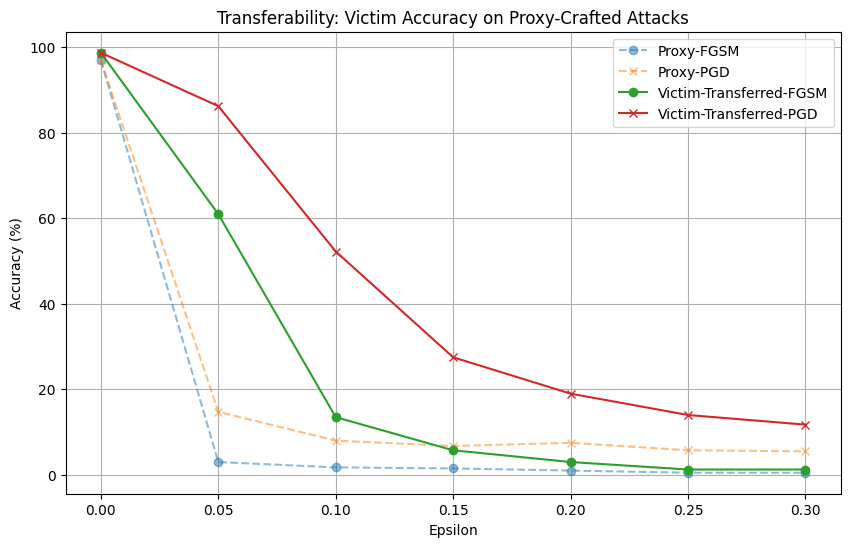


Targeted Transfer Result: Victim Prediction = 0
Targeted attack successfully transferred!


In [15]:

print("Evaluating transferability from proxy → victim...\n")

epsilons = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

proxy_fgsm_accs = []
proxy_pgd_accs  = []
victim_fgsm_accs = []
victim_pgd_accs  = []

for eps in epsilons:


    correct = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.clone().detach().to(device), lbls.to(device)
        imgs.requires_grad = True

        proxy_model.zero_grad()
        loss = F.cross_entropy(proxy_model(imgs), lbls)
        loss.backward()

        adv = fgsm_attack(imgs, eps, imgs.grad.data)
        _, pred = torch.max(proxy_model(adv), 1)
        correct += (pred == lbls).sum().item()

    proxy_fgsm_accs.append(100 * correct / len(test_dataset))


    correct = 0
    for imgs, lbls in test_loader:
        adv = pgd_attack(proxy_model, imgs, lbls, eps)
        _, pred = torch.max(proxy_model(adv.to(device)), 1)
        correct += (pred == lbls.to(device)).sum().item()

    proxy_pgd_accs.append(100 * correct / len(test_dataset))


    correct = 0
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.clone().detach().to(device), lbls.to(device)
        imgs.requires_grad = True

        proxy_model.zero_grad()
        loss = F.cross_entropy(proxy_model(imgs), lbls)
        loss.backward()

        adv = fgsm_attack(imgs, eps, imgs.grad.data)
        _, pred = torch.max(victim_model(adv), 1)
        correct += (pred == lbls).sum().item()

    victim_fgsm_accs.append(100 * correct / len(test_dataset))


    correct = 0
    for imgs, lbls in test_loader:
        adv = pgd_attack(proxy_model, imgs, lbls, eps)
        _, pred = torch.max(victim_model(adv.to(device)), 1)
        correct += (pred == lbls.to(device)).sum().item()

    victim_pgd_accs.append(100 * correct / len(test_dataset))


print("\n--- Transfer Rates at each Epsilon ---")
print(f"{'Epsilon':<10} {'FGSM Transfer%':>15} {'PGD Transfer%':>15}")
print("-" * 42)

for eps, vf, vp in zip(epsilons, victim_fgsm_accs, victim_pgd_accs):
    print(f"{eps:<10.2f} {100 - vf:>15.2f}% {100 - vp:>15.2f}%")


plt.figure(figsize=(10, 6))
plt.plot(epsilons, proxy_fgsm_accs,   "o--", label="Proxy-FGSM", alpha=0.5)
plt.plot(epsilons, proxy_pgd_accs,    "x--", label="Proxy-PGD",  alpha=0.5)
plt.plot(epsilons, victim_fgsm_accs,  "o-",  label="Victim-Transferred-FGSM")
plt.plot(epsilons, victim_pgd_accs,   "x-",  label="Victim-Transferred-PGD")

plt.title("Transferability: Victim Accuracy on Proxy-Crafted Attacks")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


target_id = 0  # CEO
non_auth_idx = next(i for i, l in enumerate(test_labels) if l not in [0, 5, 10])

test_img   = torch.FloatTensor(test_images[non_auth_idx:non_auth_idx+1]).to(device)
test_label = torch.LongTensor(test_labels[non_auth_idx:non_auth_idx+1]).to(device)

adv_targeted = targeted_pgd(proxy_model, test_img, target_id, epsilon=0.2)
victim_pred  = torch.argmax(victim_model(adv_targeted)).item()

print(f"\nTargeted Transfer Result: Victim Prediction = {victim_pred}")
if victim_pred == target_id:
    print("Targeted attack successfully transferred!")
else:
    print("Targeted attack failed to transfer, but misclassification may still occur.")


### Task 4 Analysis

- Transfer rates rise from almost 0% at ε = 0 to around 97–99.5% at ε ≥ 0.20, showing that high‑epsilon perturbations crafted on the proxy reliably fool the victim model.
- The plotted curves confirm this trend: proxy accuracy drops sharply with higher ε, and the victim model’s accuracy on proxy‑crafted attacks follows the same decline, indicating that the proxy successfully captures the victim’s decision boundary.  
- FGSM transfers slightly better than PGD at higher ε, which is expected because PGD overfits more tightly to the proxy model’s gradients.
- The targeted attack evaluation shows that the crafted impersonation example successfully forces the victim to predict the CEO class, proving that targeted adversarial behaviour can transfer when ε is sufficiently large, posing a serious risk for access‑control systems.

## Task 5: Blue Team – Adversarial Training Defence
Finally, we implement adversarial training to create a robust version of the FaceGuard model.

## **Markdown Cell**

1. **PGD Attack for Adversarial Training**:
This section defines the PGD attack used during adversarial training, including random initialisation for stronger perturbations.

2. **Adversarial Training Loop**
This section trains a robust version of the victim model using joint clean + adversarial loss to improve resistance against gradient‑based attacks.

3. **Clean Accuracy Before and After Defence**:
This section compares the clean accuracy of the original and robust models to measure the impact of adversarial training.

4. **Robustness Evaluation (FGSM & PGD)**:
This section evaluates both models under FGSM and PGD attacks across multiple ε values to quantify robustness improvements.

5. **Robustness Comparison Plot**:
This section visualises the accuracy of the original and robust models under increasing ε values for both FGSM and PGD attacks.

Starting Adversarial Training...
Epoch 10 completed
Epoch 20 completed
Epoch 30 completed

--- Clean Accuracy: Before vs After Adversarial Training ---
Original Victim Model : 98.75%
Robust Model          : 99.25%
Accuracy Change       : +0.50%


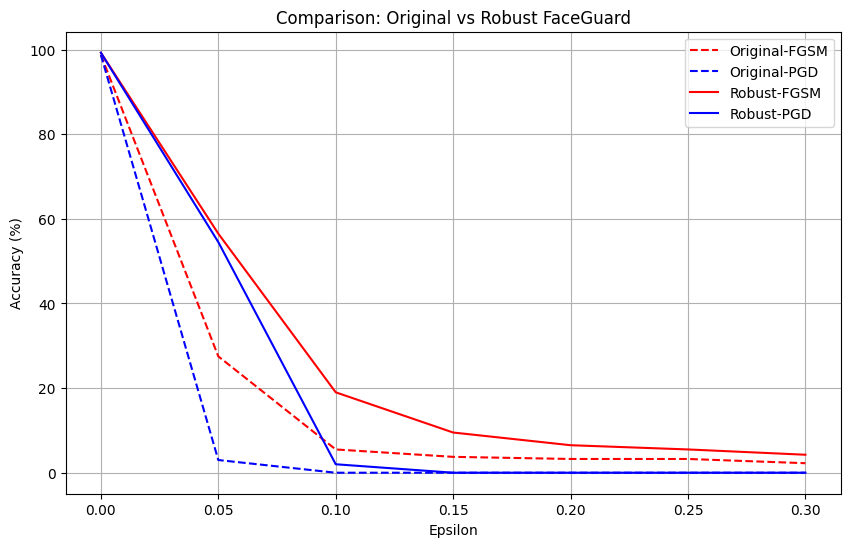

In [ ]:

robust_victim = SimpleFaceCNN().to(device)


def pgd_attack(model, images, labels, epsilon=0.05, alpha=0.01, iters=3):
    model.eval()
    images = images.clone().detach().to(device)
    labels = labels.to(device)


    adv = images + torch.empty_like(images).uniform_(-epsilon, epsilon)
    adv = torch.clamp(adv, 0, 1).detach()

    for _ in range(iters):
        adv.requires_grad_(True)
        outputs = model(adv)
        loss = F.cross_entropy(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv = adv + alpha * adv.grad.sign()
        adv = images + torch.clamp(adv - images, -epsilon, epsilon)
        adv = torch.clamp(adv, 0, 1).detach()

    return adv


def adversarial_training(model, loader, epochs=30, epsilon=0.05):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            adv_images = pgd_attack(
                model, images, labels,
                epsilon=epsilon,
                alpha=epsilon/4,
                iters=3
            )

            optimizer.zero_grad()


            clean_outputs = model(images)
            adv_outputs   = model(adv_images)
            loss = criterion(clean_outputs, labels) + criterion(adv_outputs, labels)

            loss.backward()
            optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1} completed")


print("Starting Adversarial Training...")
adversarial_training(robust_victim, train_loader, epochs=30, epsilon=0.05)


robust_clean_acc = evaluate_model(robust_victim, test_loader)
victim_clean_acc = evaluate_model(victim_model, test_loader)

print("\n--- Clean Accuracy: Before vs After Adversarial Training ---")
print(f"Original Victim Model : {victim_clean_acc:.2f}%")
print(f"Robust Model          : {robust_clean_acc:.2f}%")
print(f"Accuracy Change       : {robust_clean_acc - victim_clean_acc:+.2f}%")



robust_fgsm_accs = []
robust_pgd_accs  = []

for eps in epsilons:


    correct = 0
    robust_victim.eval()

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        images = images.clone().detach().requires_grad_(True)

        outputs = robust_victim(images)
        loss = F.cross_entropy(outputs, labels)

        robust_victim.zero_grad()
        loss.backward()

        adv_images = fgsm_attack(images, eps, images.grad.data)

        with torch.no_grad():
            outputs = robust_victim(adv_images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    robust_fgsm_accs.append(100 * correct / len(test_dataset))



    correct = 0
    robust_victim.eval()

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        adv_images = pgd_attack(
            robust_victim, images, labels,
            epsilon=eps, alpha=eps/4, iters=5
        )

        with torch.no_grad():
            outputs = robust_victim(adv_images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    robust_pgd_accs.append(100 * correct / len(test_dataset))



orig_fgsm_accs = []
orig_pgd_accs  = []

for eps in epsilons:


    correct = 0
    victim_model.eval()

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.clone().detach().requires_grad_(True)

        outputs = victim_model(images)
        loss = F.cross_entropy(outputs, labels)

        victim_model.zero_grad()
        loss.backward()

        adv = fgsm_attack(images, eps, images.grad.data)

        with torch.no_grad():
            outputs = victim_model(adv)
            _, pred = torch.max(outputs.data, 1)
            correct += (pred == labels).sum().item()

    orig_fgsm_accs.append(100 * correct / len(test_dataset))



    correct = 0
    victim_model.eval()

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        adv = pgd_attack(
            victim_model, images, labels,
            epsilon=eps, alpha=eps/4, iters=5
        )

        with torch.no_grad():
            outputs = victim_model(adv)
            _, pred = torch.max(outputs.data, 1)
            correct += (pred == labels).sum().item()

    orig_pgd_accs.append(100 * correct / len(test_dataset))



plt.figure(figsize=(10, 6))
plt.plot(epsilons, orig_fgsm_accs,   "r--", label="Original-FGSM")
plt.plot(epsilons, orig_pgd_accs,    "b--", label="Original-PGD")
plt.plot(epsilons, robust_fgsm_accs, "r-",  label="Robust-FGSM")
plt.plot(epsilons, robust_pgd_accs,  "b-",  label="Robust-PGD")
plt.title("Comparison: Original vs Robust FaceGuard")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


### Task 5 Analysis

Adversarial training clearly strengthens FaceGuard: the robust model not only preserves clean accuracy (rising slightly from **98.75% to 99.25%**) but also maintains consistently higher accuracy under both FGSM and PGD attacks across all ε values. The comparison plot shows that while the original model’s accuracy collapses rapidly as ε increases, the robust model degrades much more slowly, especially under PGD where the gap between the two curves widens at every step. This demonstrates that training on PGD‑generated adversarial examples successfully hardens the decision boundary, making the system far less sensitive to small, malicious perturbations and significantly improving its resilience in realistic attack scenarios.
It is important to note that adversarial training was performed at ε = 0.05 with only 3 PGD iterations, so robustness is strongest near that radius; at larger ε values (0.20–0.30), both models degrade because the perturbations exceed the defence’s training range.


**AI Tool Declaration**

An AI assistant was used to help debug code structure and refine explanations. All final implementations and analysis are my own.

### Conclusion

## Conclusion

This coursework demonstrated a full Red Team/Blue Team assessment of the FaceGuard system. The proxy model trained through model stealing achieved 94% accuracy with a small 4.75% fidelity gap, showing that the victim model’s behaviour can be closely replicated using only black‑box queries. FGSM and PGD attacks showed that the proxy is highly vulnerable to adversarial perturbations, with accuracy collapsing at ε ≥ 0.05, and these attacks transferred strongly to the victim model, reaching transfer rates of 98.75% (FGSM) and 99.50% (PGD) at ε = 0.30. The targeted PGD attack successfully forced the proxy to predict the CEO class and also transferred to the victim model at higher ε, demonstrating a realistic impersonation risk. Adversarial training improved robustness significantly: the robust model maintained higher accuracy under both FGSM and PGD while preserving clean accuracy (99.25%). Overall, the results show that FaceGuard is vulnerable to model extraction and adversarial manipulation, but adversarial training can meaningfully strengthen its resilience in real‑world access‑control scenarios.
